# **Food Delivery Time Prediction Using Linear Regression**


## Importing Libraries

- Import libraries for data handling, visualization, and numerical analysis.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset

- Load the CSV file into a pandas DataFrame and displayed it to inspect the rows and columns.

In [18]:
df = pd.read_csv('../data/food_delivery_data.csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### Inspecting the Dataset

- Use `df.info()` to check the row count, column names, data types, and missing values.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


### Checking Summary Statistics

- Use `df.describe()` to review the count, average, minimum, maximum, and quartile values for numeric columns.

In [20]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


### Checking Missing Values

- Count the missing values in each column to identify fields that need cleaning.

In [21]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

### Checking Duplicate Rows

- Check for duplicate rows to make sure the dataset does not contain repeated records.

In [22]:
df[df.duplicated()]

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


### Copying the Data

- Copy the original DataFrame before cleaning so the raw data stays unchanged.

In [23]:
df_copy = df.copy()

### Filling Categorical Missing Values

- Fill missing values in text columns with the most frequent category (mode).

In [24]:
categorical_col = ['Weather', 'Traffic_Level', 'Time_of_Day']

for col in categorical_col:
    df_copy[col] = df_copy[col].fillna(df_copy[col].mode()[0])

### Checking Numeric Data

- Plot the courier experience distribution before filling its missing values.

<Axes: xlabel='Courier_Experience_yrs', ylabel='Count'>

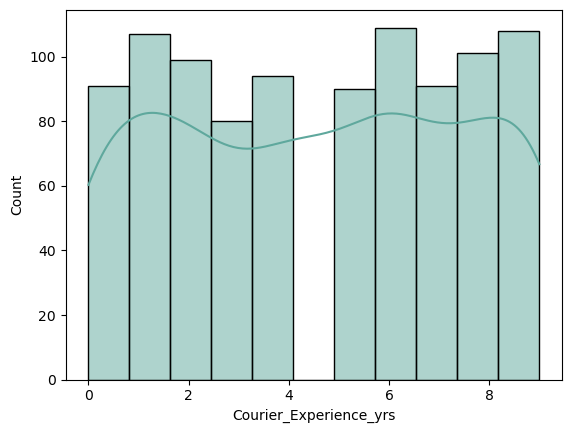

In [25]:
sns.histplot(df_copy['Courier_Experience_yrs'], kde=True, color='#5FA89D')

### Filling Numeric Missing Values

- Fill missing courier experience values with the median to reduce the effect of extreme values.

In [26]:
df_copy['Courier_Experience_yrs'] = df_copy['Courier_Experience_yrs'].fillna(df_copy['Courier_Experience_yrs'].median())

### Verifying the Cleaning

- Check the missing-value counts again to confirm that the required columns are complete.

In [27]:
df_copy.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

### Previewing the Cleaned Data

- Display the first ten rows to confirm that the cleaned data still looks correct.

In [28]:
df_copy.head(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,Morning,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


## Exploring the Cleaned Data

- Explore relationships between the variables before selecting features for the model.

### Pair Plot

- Compare numeric variables with pairwise scatter plots to spot visible relationships.

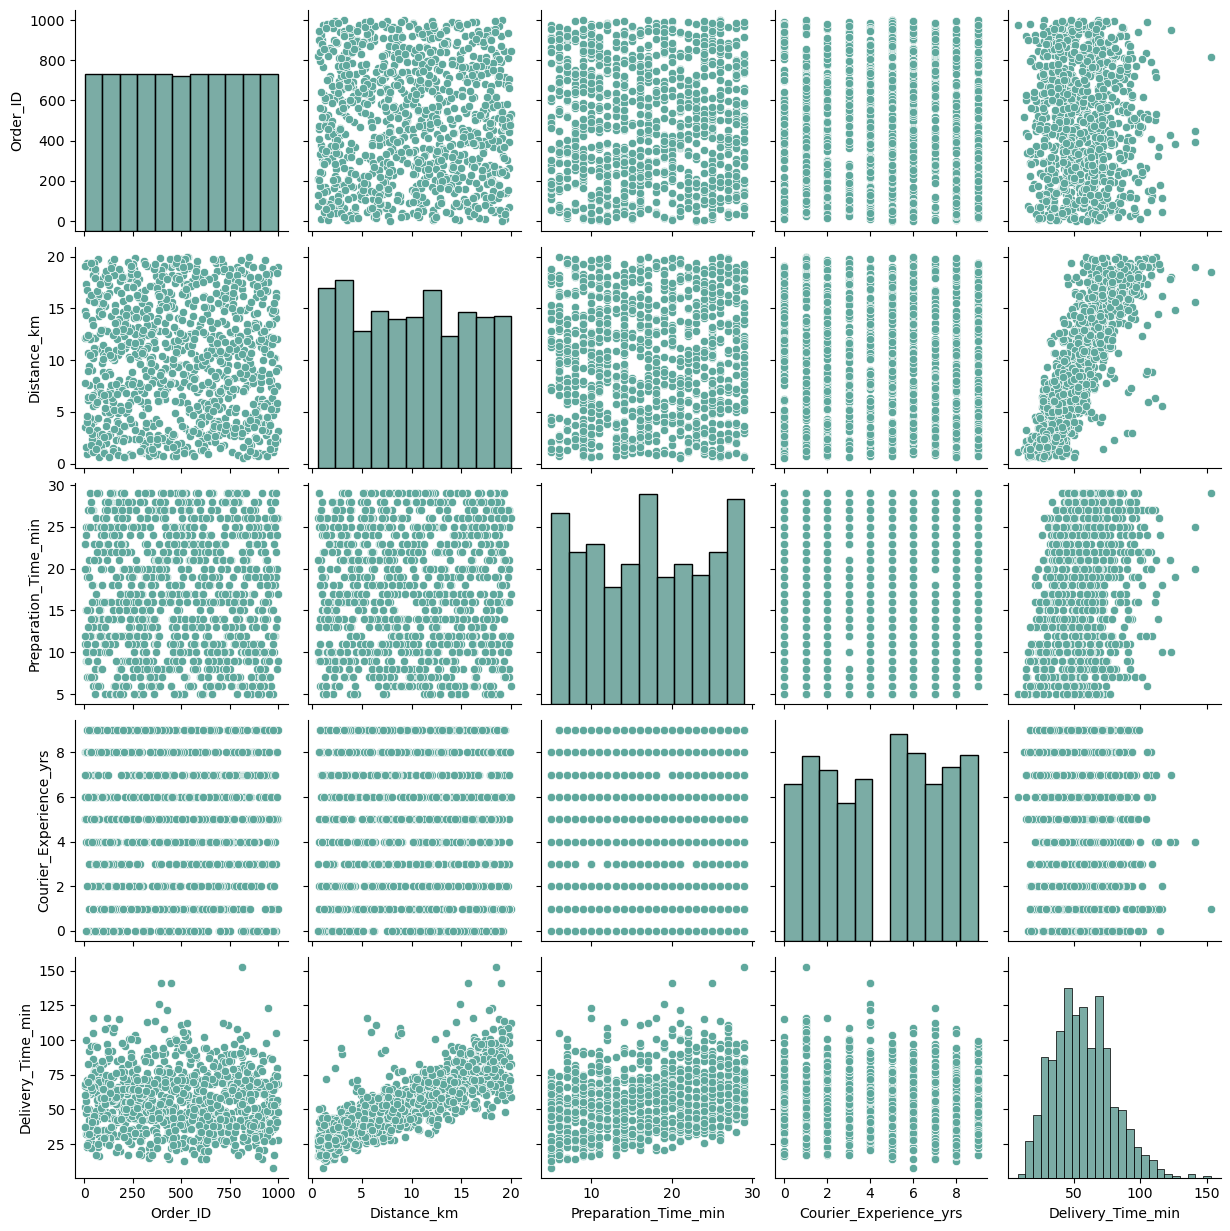

In [29]:
sns.pairplot(df_copy, plot_kws={'color': '#5FA89D'}, diag_kws={'color': '#4F9187'})

### Correlation with Delivery Time

- Calculate the correlation of each numeric feature with delivery time to identify possible linear relationships.

In [30]:
corr = df_copy.corr(numeric_only=True)['Delivery_Time_min'].sort_values()
print(corr)

Courier_Experience_yrs   -0.089111
Order_ID                 -0.036650
Preparation_Time_min      0.307350
Distance_km               0.780998
Delivery_Time_min         1.000000
Name: Delivery_Time_min, dtype: float64


### Correlation Heatmap

- Display the correlations as a heatmap for an easier visual comparison.

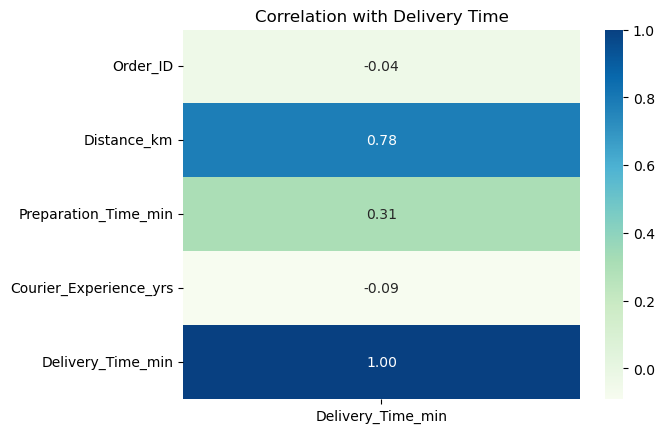

In [31]:
corr = df.corr(numeric_only=True)[['Delivery_Time_min']]
sns.heatmap(corr, annot=True, cmap='GnBu', fmt='.2f')
plt.title('Correlation with Delivery Time')
plt.show()

### ANOVA Test

- Compare average delivery times across categories such as weather, traffic, time of day, and vehicle type.

In [32]:
from scipy.stats import f_oneway

anova_result = {}

for col in ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']:
    
    groups = [
        group['Delivery_Time_min'].dropna().values
        for name, group in df.groupby(col)
    ]
    
    f_stat, p_value = f_oneway(*groups)
    
    anova_result[col] = {
        'F-statistic': f_stat,
        'P-value': p_value
    }

anova_df = pd.DataFrame(anova_result).T

anova_df['significance (p < 0.05)'] = anova_df['P-value'] < 0.05

anova_df = anova_df.sort_values(
    by='F-statistic',
    ascending=False
)

print(anova_df)

               F-statistic       P-value  significance (p < 0.05)
Traffic_Level    20.167114  2.625845e-09                     True
Weather          10.456547  2.704057e-08                     True
Vehicle_Type      0.589374  5.548673e-01                    False
Time_of_Day       0.367448  7.765221e-01                    False


### One-Hot Encoding

- Convert selected text columns into numeric columns so the regression model can use them.

In [33]:
df_encoded = df_copy.drop(
    ['Courier_Experience_yrs', 'Vehicle_Type', 'Time_of_Day', 'Order_ID'],
    axis=1
)

df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Weather', 'Traffic_Level'],
    drop_first=True
)

df_encoded = df_encoded.astype('int64')

df_encoded.head(10)

,Distance_km,Preparation_Time_min,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium
0,7,12,43,0,0,0,1,1,0
1,16,20,84,0,0,0,0,0,1
2,9,28,59,1,0,0,0,1,0
3,7,5,37,0,1,0,0,0,1
4,19,16,68,0,0,0,0,1,0
5,19,8,57,0,0,0,0,1,0
6,9,12,49,0,0,0,0,1,0
7,17,5,46,0,0,0,0,0,1
8,1,20,35,0,0,1,0,1,0
9,10,29,73,1,0,0,0,1,0


**Output:** The encoded table now contains numeric feature columns and the `Delivery_Time_min` target.

## Defining Features and Target

- Separate the input features (`x`) from the target (`y`), which is `Delivery_Time_min`.

In [34]:
x = df_encoded.drop('Delivery_Time_min', axis=1)
y = df_encoded['Delivery_Time_min']

## Splitting the Data

- Split the data into an 80% training set and a 20% testing set to evaluate the model on unseen data.

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## Training the Linear Regression Model

- Create a Linear Regression model and train it using the training data.

In [36]:
from sklearn.linear_model import LinearRegression

delivery_time_model = LinearRegression()

In [37]:
delivery_time_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Making Predictions

- Use the trained model to predict delivery times for the test data.

In [38]:

from sklearn.metrics import mean_squared_error, r2_score

y_test_prediction = delivery_time_model.predict(x_test)


## Evaluating the Model

- Measure the prediction error using MSE, R², and adjusted R².

In [39]:
model_mse = mean_squared_error(y_test, y_test_prediction)
model_r2 = r2_score(y_test, y_test_prediction)
model_adjusted_r2 = 1 - (1 - model_r2) * (df_copy.shape[0] - 1) / (df_encoded.shape[0] - df_encoded.shape[1] - 1)

print("Model Performance:-")
print("Mean Squared Error:", model_mse) 
print("R-squared:", model_r2)
print("Adjusted R-squared:", model_adjusted_r2)

Model Performance:-
Mean Squared Error: 82.50910394093549
R-squared: 0.8159211548101595
Adjusted R-squared: 0.8142477107629791


**Output:** The model explains about 81.6% of the variation in delivery time, indicating a good overall fit. The MSE of 82.51 shows the magnitude of prediction errors, while the Adjusted R² of 81.4% confirms that the model maintains a good fit after accounting for the number of features.

In [40]:
#evaluating the delivery time model - overfit, underfit, or good fit?
y_test_prediction = delivery_time_model.predict(x_test)
y_train_prediction = delivery_time_model.predict(x_train)
test_r2 = r2_score(y_test, y_test_prediction)
train_r2 = r2_score(y_train, y_train_prediction)

print("Model R-squared on Test Set:", test_r2)
print("Model R-squared on Train Set:", train_r2)

Model R-squared on Test Set: 0.8159211548101595
Model R-squared on Train Set: 0.7518712036962997


**Output:** The model achieves an R² of 75.2% on the training set and 81.6% on the test set, showing that it performs well on unseen data and does not show a major gap between training and test performance

### Actual vs Predicted Values

- Plot actual delivery times against predicted times to visually check the model's performance.

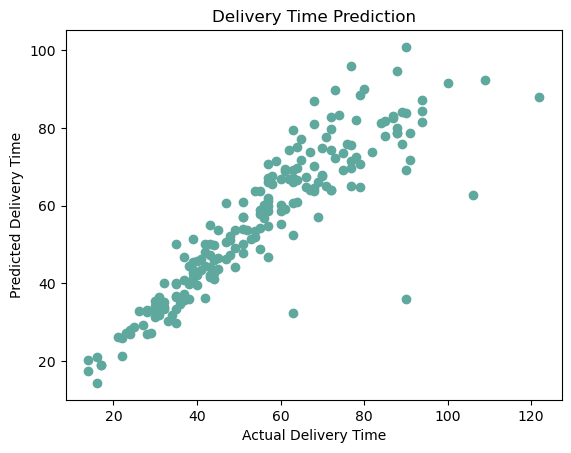

In [41]:
plt.scatter(y_test, y_test_prediction, color='#5FA89D')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Delivery Time Prediction")
plt.show()

**Output:** Most predictions are close to actual values, showing a good model fit, with a few larger prediction errors.

### Calculating Residuals

- Calculate the difference between actual and predicted delivery times.

In [42]:
residuals = y_test - y_test_prediction

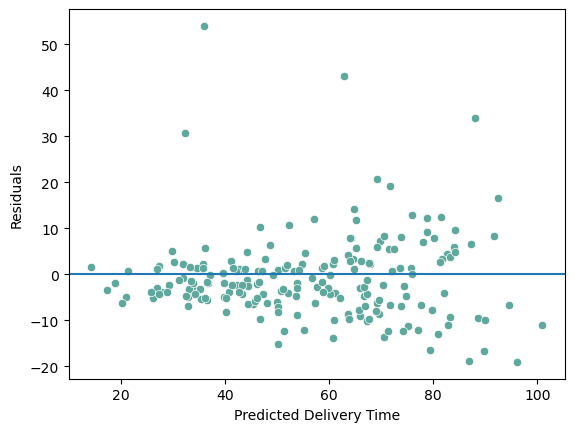

In [43]:
sns.scatterplot(x=y_test_prediction, y=residuals, color='#5FA89D')
plt.axhline(0)
plt.xlabel('Predicted Delivery Time')
plt.ylabel('Residuals')
plt.show()

**Output:** Residuals are mostly scattered around 0, indicating a good fit, with a few larger errors.

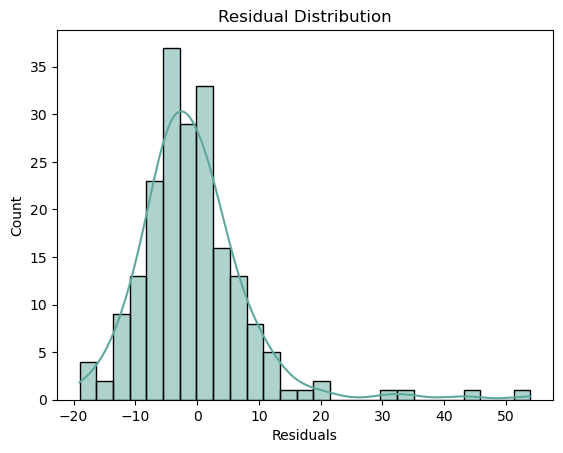

In [44]:
sns.histplot(residuals, kde=True, color='#5FA89D')
plt.xlabel('Residuals')
plt.title('Residual Distribution')
plt.show()

**Output:** The residuals are mostly small, but the distribution is slightly right-skewed due to a few larger positive errors.

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_test_prediction)
rmse = np.sqrt(mean_squared_error(y_test, y_test_prediction))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6.245805118889064
RMSE: 9.083452203922002


**Output:** The model’s predictions are off by about 6.25 minutes on average (MAE), while the RMSE of 9.08 minutes indicates a few larger errors.

### Final Conclusion

- The Linear Regression model performs well, explaining 81.6% of the variation in delivery time. Its predictions are off by about 6.25 minutes on average, with a few larger errors. Overall, the model provides a reasonable and useful prediction of food delivery time.

### Save the Trained Model

- Save the trained Linear Regression model as a `.pkl` file so it can be reused in the Streamlit application without retraining.

In [46]:
import joblib

joblib.dump(delivery_time_model, 'delivery_time_model.pkl')

['delivery_time_model.pkl']